In [1]:
!pip install ultralytics -q

import os, glob, random, shutil
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

print("✓ All imports OK")
print("✓ PyTorch :", torch.__version__)
print("✓ CUDA    :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✓ Device  :", device)

!nvidia-smi | grep "Tesla\|T4\|GPU"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:0000:01
✓ All imports OK
✓ PyTorch : 2.10.0+cu128
✓ CUDA    : True
✓ Device  : cuda
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
|   1  Tesla T4                       Off |   00000000:00:05.0 Off |                    0 |
|  GPU   GI   CI              PID   Type   Process name                        GPU Memory |


In [2]:
import os, glob

# Check all mounted datasets
for dataset in os.listdir("/kaggle/input"):
    print(f"\n{'='*40}")
    print(f"Dataset: {dataset}")
    print(f"{'='*40}")
    for root, dirs, files in os.walk(f"/kaggle/input/{dataset}"):
        level = root.replace(f"/kaggle/input/{dataset}","").count(os.sep)
        if level < 4:
            print("  "*level + os.path.basename(root) + "/")
            for f in files[:3]:
                print("  "*(level+1) + f)

# Hunt for video files
fight_vids = []
for ext in ['*.avi', '*.mp4', '*.mov']:
    fight_vids += glob.glob(f"/kaggle/input/**/{ext}", recursive=True)

print(f"\n✓ Total video files found: {len(fight_vids)}")
if fight_vids:
    print("Sample paths:")
    for p in fight_vids[:5]:
        print(" ", p)


Dataset: datasets
datasets/
  naveenk903/
    movies-fight-detection-dataset/
      Peliculas/
  vulamnguyen/
    rwf2000/
      RWF-2000/

✓ Total video files found: 2100
Sample paths:
  /kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas/fights/newfi49.avi
  /kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas/fights/newfi6.avi
  /kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas/fights/newfi19.avi
  /kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas/fights/newfi7.avi
  /kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas/fights/newfi77.avi


In [3]:
import glob

# ── Dataset 1: RWF-2000 ──────────────────────────────────────
rwf_base = "/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000"

rwf_fight    = glob.glob(f"{rwf_base}/**/Fight/*.avi",    recursive=True)
rwf_fight   += glob.glob(f"{rwf_base}/**/Fight/*.mp4",    recursive=True)
rwf_nonfight = glob.glob(f"{rwf_base}/**/NonFight/*.avi", recursive=True)
rwf_nonfight+= glob.glob(f"{rwf_base}/**/NonFight/*.mp4", recursive=True)

print("── RWF-2000 ────────────────────────────")
print(f"  Fight    : {len(rwf_fight)}")
print(f"  NonFight : {len(rwf_nonfight)}")

# ── Dataset 2: Movies fight ──────────────────────────────────
mov_base = "/kaggle/input/datasets/naveenk903/movies-fight-detection-dataset/Peliculas"

mov_fight    = glob.glob(f"{mov_base}/fights/*.avi")
mov_fight   += glob.glob(f"{mov_base}/fights/*.mp4")
mov_nonfight = glob.glob(f"{mov_base}/noFights/*.avi")
mov_nonfight+= glob.glob(f"{mov_base}/noFights/*.mp4")
mov_nonfight+= glob.glob(f"{mov_base}/no-fights/*.avi")
mov_nonfight+= glob.glob(f"{mov_base}/no-fights/*.mp4")

# Auto-find folders if above returns 0
if not mov_fight:
    for root, dirs, files in os.walk(mov_base):
        vids = [f for f in files if f.endswith(('.avi','.mp4'))]
        if vids:
            print(f"  Found {len(vids)} videos in: {root}")

print("\n── Movies Fight Dataset ────────────────")
print(f"  Fight    : {len(mov_fight)}")
print(f"  NonFight : {len(mov_nonfight)}")

# ── Combined ─────────────────────────────────────────────────
all_fight    = rwf_fight    + mov_fight
all_nonfight = rwf_nonfight + mov_nonfight

print("\n── Combined Total ──────────────────────")
print(f"  Fight    : {len(all_fight)}")
print(f"  NonFight : {len(all_nonfight)}")
print(f"  Total    : {len(all_fight) + len(all_nonfight)}")

── RWF-2000 ────────────────────────────
  Fight    : 1000
  NonFight : 1000

── Movies Fight Dataset ────────────────
  Fight    : 100
  NonFight : 0

── Combined Total ──────────────────────
  Fight    : 1100
  NonFight : 1000
  Total    : 2100


RWF-2000 is perfectly balanced (1000/1000). The movies dataset has no nonfight folder so we'll use RWF-2000 only because balanced dataset is better than a slightly larger imbalanced one.

✓ Frame shape : (16, 224, 224, 3)


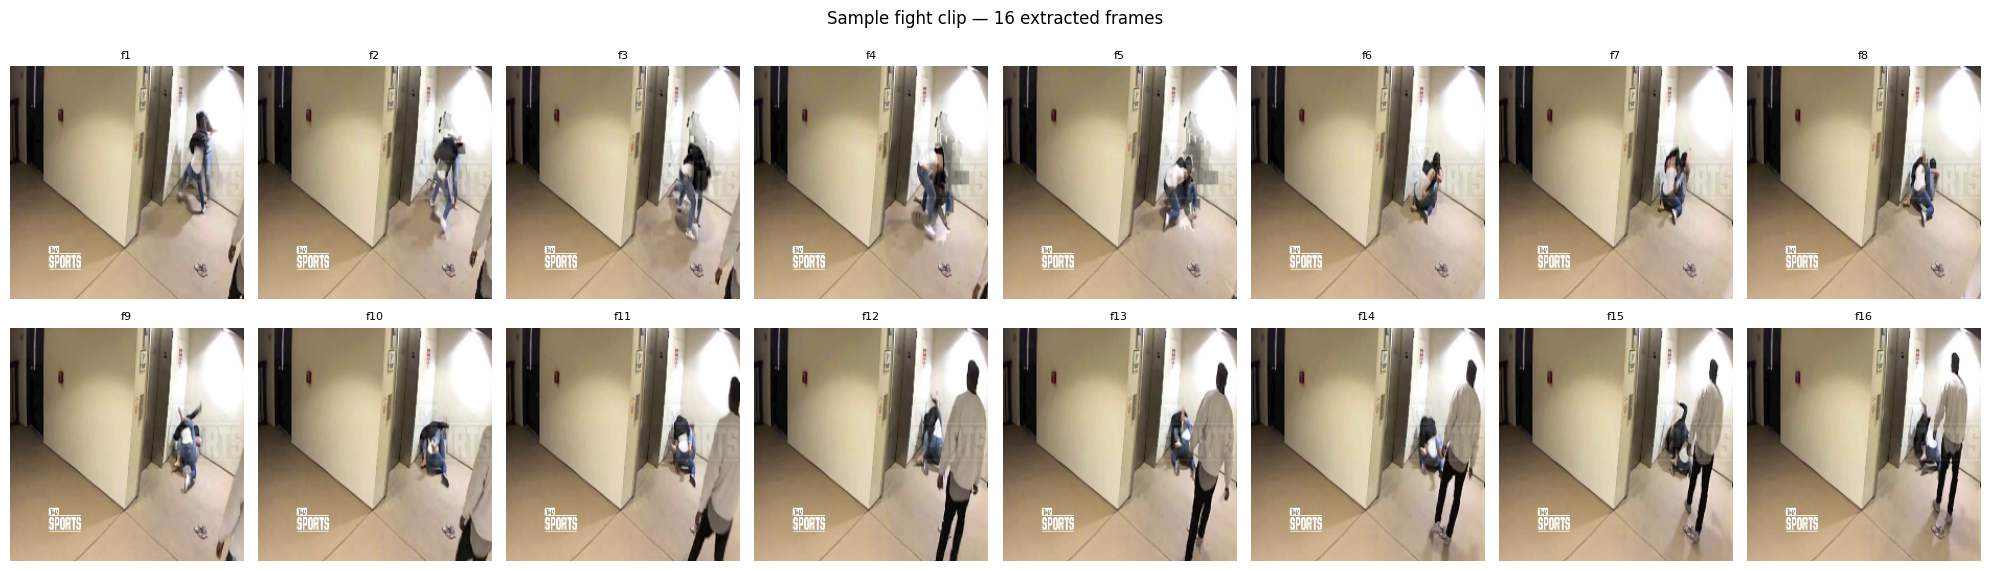

In [4]:
import random, numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

NUM_FRAMES = 16
IMG_SIZE   = 224

def extract_frames(video_path, num_frames=NUM_FRAMES):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((num_frames, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    indices = np.linspace(0, total-1, num_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    while len(frames) < num_frames:
        frames.append(frames[-1] if frames
                      else np.zeros((IMG_SIZE,IMG_SIZE,3), dtype=np.uint8))
    return np.array(frames[:num_frames])

# Quick visual check on one fight clip
sample = extract_frames(rwf_fight[0])
print(f"✓ Frame shape : {sample.shape}")  # (16, 224, 224, 3)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample[i])
    ax.axis('off')
    ax.set_title(f"f{i+1}", fontsize=8)
plt.suptitle("Sample fight clip — 16 extracted frames")
plt.tight_layout()
plt.show()

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_val = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

class FightDataset(Dataset):
    def __init__(self, video_paths, labels,
                 num_frames=NUM_FRAMES, transform=None):
        self.video_paths = video_paths
        self.labels      = labels
        self.num_frames  = num_frames
        self.transform   = transform

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        frames = extract_frames(self.video_paths[idx],
                                self.num_frames)
        # Use middle frame as representative single frame
        mid   = self.num_frames // 2
        frame = frames[mid]
        if self.transform:
            frame = self.transform(frame)
        return frame, self.labels[idx]

# Use RWF-2000 only — perfectly balanced
all_vids   = rwf_fight + rwf_nonfight
all_labels = [1]*len(rwf_fight) + [0]*len(rwf_nonfight)

# Shuffle
combined = list(zip(all_vids, all_labels))
random.shuffle(combined)
all_vids, all_labels = zip(*combined)

# 80/10/10 split
n       = len(all_vids)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_vids,  train_labels = all_vids[:n_train],          all_labels[:n_train]
val_vids,    val_labels   = all_vids[n_train:n_train+n_val], all_labels[n_train:n_train+n_val]
test_vids,   test_labels  = all_vids[n_train+n_val:],    all_labels[n_train+n_val:]

print(f"✓ Train : {len(train_vids)} clips")
print(f"✓ Val   : {len(val_vids)}   clips")
print(f"✓ Test  : {len(test_vids)}  clips")

train_ds = FightDataset(train_vids, train_labels, transform=transform)
val_ds   = FightDataset(val_vids,   val_labels,   transform=transform_val)
test_ds  = FightDataset(test_vids,  test_labels,  transform=transform_val)

train_loader = DataLoader(train_ds, batch_size=32,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)

print("✓ DataLoaders ready")

✓ Train : 1600 clips
✓ Val   : 200   clips
✓ Test  : 200  clips
✓ DataLoaders ready


In [6]:
class FightClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        in_features = backbone.classifier[3].in_features
        backbone.classifier[3] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

model_fight = FightClassifier(num_classes=2).to(device)

total  = sum(p.numel() for p in model_fight.parameters())
train_ = sum(p.numel() for p in model_fight.parameters()
             if p.requires_grad)
print(f"✓ Total params     : {total:,}")
print(f"✓ Trainable params : {train_:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fight.parameters(),
                              lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=20)
print("✓ Model ready")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 158MB/s]


✓ Total params     : 1,519,906
✓ Trainable params : 1,519,906
✓ Model ready


In [7]:
EPOCHS       = 20
best_val_acc = 0.0
history      = {'train_loss':[], 'val_loss':[],
                'train_acc':[],  'val_acc':[]}

for epoch in range(EPOCHS):
    # ── Train ────────────────────────────────────────────────
    model_fight.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model_fight(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += labels.size(0)

    # ── Validate ─────────────────────────────────────────────
    model_fight.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out   = model_fight(imgs)
            loss  = criterion(out, labels)
            v_loss    += loss.item()
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total   += labels.size(0)

    scheduler.step()

    t_acc = t_correct / t_total
    v_acc = v_correct / v_total
    t_l   = t_loss / len(train_loader)
    v_l   = v_loss / len(val_loader)

    history['train_loss'].append(t_l)
    history['val_loss'].append(v_l)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Save best
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model_fight.state_dict(),
                   "/kaggle/working/fight_best.pth")
        flag = " ← best ✓"
    else:
        flag = ""

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Loss {t_l:.4f}/{v_l:.4f} | "
          f"Acc {t_acc:.4f}/{v_acc:.4f}{flag}")

print(f"\n✓ Done — best val accuracy: {best_val_acc:.4f}")

Epoch  1/20 | Loss 0.6410/0.5703 | Acc 0.6194/0.6650 ← best ✓
Epoch  2/20 | Loss 0.5034/0.4897 | Acc 0.7412/0.7400 ← best ✓
Epoch  3/20 | Loss 0.4273/0.4555 | Acc 0.7887/0.7600 ← best ✓
Epoch  4/20 | Loss 0.3568/0.4285 | Acc 0.8413/0.7750 ← best ✓
Epoch  5/20 | Loss 0.2904/0.4097 | Acc 0.8756/0.8100 ← best ✓
Epoch  6/20 | Loss 0.2560/0.4077 | Acc 0.8944/0.8200 ← best ✓
Epoch  7/20 | Loss 0.2171/0.4307 | Acc 0.9169/0.8100
Epoch  8/20 | Loss 0.1830/0.4369 | Acc 0.9319/0.8050
Epoch  9/20 | Loss 0.1431/0.4417 | Acc 0.9506/0.8050
Epoch 10/20 | Loss 0.1108/0.4348 | Acc 0.9594/0.8250 ← best ✓
Epoch 11/20 | Loss 0.1031/0.4706 | Acc 0.9675/0.8050
Epoch 12/20 | Loss 0.0890/0.4947 | Acc 0.9694/0.8100
Epoch 13/20 | Loss 0.0755/0.5036 | Acc 0.9725/0.8000
Epoch 14/20 | Loss 0.0692/0.5065 | Acc 0.9731/0.8200
Epoch 15/20 | Loss 0.0653/0.5267 | Acc 0.9800/0.8150
Epoch 16/20 | Loss 0.0594/0.5312 | Acc 0.9838/0.8200
Epoch 17/20 | Loss 0.0568/0.5394 | Acc 0.9800/0.8200
Epoch 18/20 | Loss 0.0610/0.5458 | A

── Test Set Results ────────────────────────
              precision    recall  f1-score   support

    NonFight       0.78      0.72      0.75        93
       Fight       0.77      0.82      0.80       107

    accuracy                           0.78       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.78      0.77       200



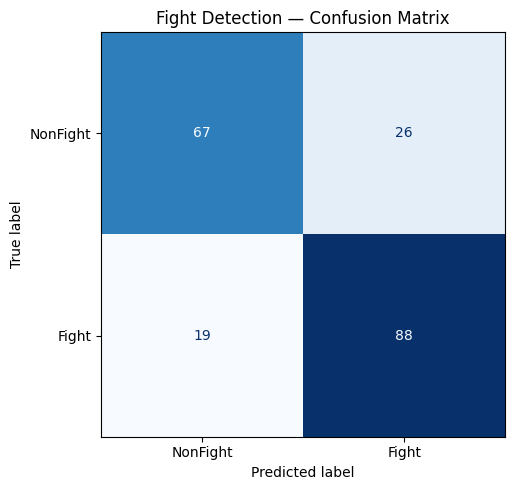

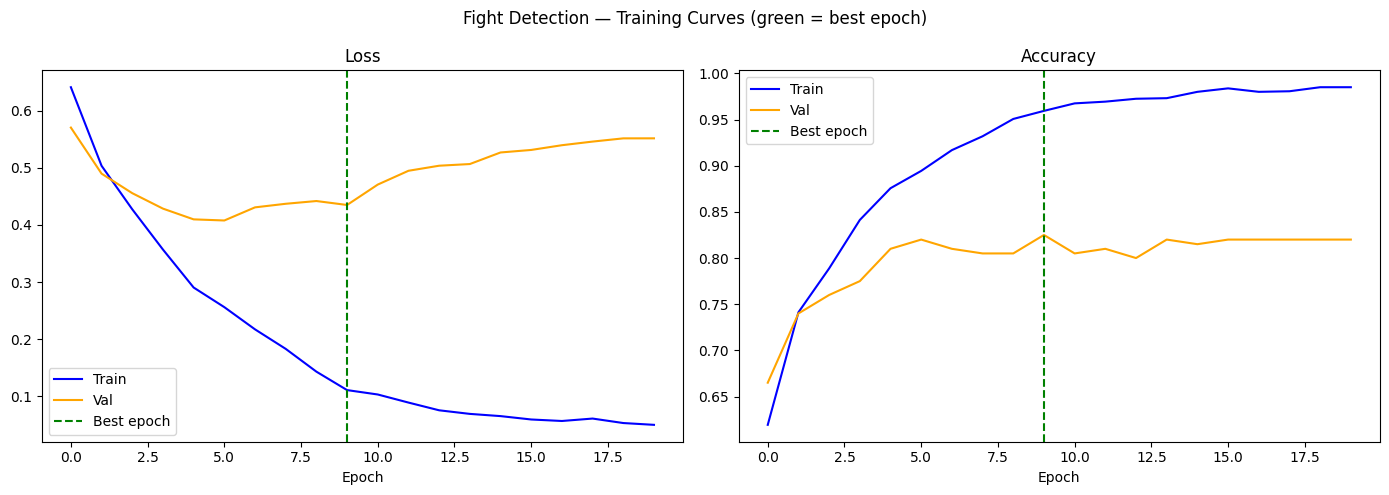


✓ Download these from Output panel:
  → fight_best.pth
  → fight_metrics.txt
  → fight_confusion_matrix.png
  → fight_training_curves.png


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load best weights (epoch 10)
model_fight.load_state_dict(
    torch.load("/kaggle/working/fight_best.pth"))
model_fight.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(device)
        preds = model_fight(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

# ── Test report ──────────────────────────────────────────────
print("── Test Set Results ────────────────────────")
report = classification_report(all_true, all_preds,
             target_names=['NonFight','Fight'])
print(report)


# ── Save metrics ─────────────────────────────────────────────
with open("/kaggle/working/fight_metrics.txt","w") as f:
    f.write("Fight Detection — Evaluation Report\n")
    f.write("="*40 + "\n")
    f.write(f"Model       : MobileNetV3-Small\n")
    f.write(f"Dataset     : RWF-2000\n")
    f.write(f"Train clips : {len(train_vids)}\n")
    f.write(f"Val clips   : {len(val_vids)}\n")
    f.write(f"Test clips  : {len(test_vids)}\n")
    f.write(f"Best val acc: {best_val_acc:.4f}\n")
    f.write(f"Best epoch  : 10/20\n\n")
    f.write(report)

# ── Confusion matrix ─────────────────────────────────────────
cm   = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm,
           display_labels=['NonFight','Fight'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Fight Detection — Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/fight_confusion_matrix.png", dpi=150)
plt.show()

# ── Training curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history['train_loss'], label='Train', color='blue')
axes[0].plot(history['val_loss'],   label='Val',   color='orange')
axes[0].axvline(x=9, color='green', linestyle='--', label='Best epoch')
axes[0].set_title('Loss'); axes[0].legend()
axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'],  label='Train', color='blue')
axes[1].plot(history['val_acc'],    label='Val',   color='orange')
axes[1].axvline(x=9, color='green', linestyle='--', label='Best epoch')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[1].set_xlabel('Epoch')

plt.suptitle("Fight Detection — Training Curves (green = best epoch)")
plt.tight_layout()
plt.savefig("/kaggle/working/fight_training_curves.png", dpi=150)
plt.show()

print("\n✓ Download these from Output panel:")
print("  → fight_best.pth")
print("  → fight_metrics.txt")
print("  → fight_confusion_matrix.png")
print("  → fight_training_curves.png")

To take the sample data for evaluation

In [1]:
import shutil, os

# Copy 3 fight clips + 3 nonfight clips to output for download
rwf_base  = "/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000"

import glob
fight_clips    = glob.glob(f"{rwf_base}/**/Fight/*.avi",    recursive=True)[:3]
nonfight_clips = glob.glob(f"{rwf_base}/**/NonFight/*.avi", recursive=True)[:3]

os.makedirs("/kaggle/working/test_clips", exist_ok=True)

for i, clip in enumerate(fight_clips):
    shutil.copy(clip, f"/kaggle/working/test_clips/fight_{i+1}.avi")
    print(f"✓ Copied fight clip {i+1}")

for i, clip in enumerate(nonfight_clips):
    shutil.copy(clip, f"/kaggle/working/test_clips/nonfight_{i+1}.avi")
    print(f"✓ Copied nonfight clip {i+1}")

print("\n✓ Download these 6 clips from Output panel")

✓ Copied fight clip 1
✓ Copied fight clip 2
✓ Copied fight clip 3
✓ Copied nonfight clip 1
✓ Copied nonfight clip 2
✓ Copied nonfight clip 3

✓ Download these 6 clips from Output panel
